# Observation ladder (P0→F2) and the arrival-only age pivot

This notebook walks through how **data-availability rungs** map to retail systems, why the production filter stopped learning ages in store (ADR **0105**), and what **FIL-11 Stage A** actually measured before that pivot.

The ladder is implemented as one **`RichObs`** schema plus **`mask_for(scenario)`** masks (ADR **0086**). Missing fields are **`UNOBSERVED`**, never numeric zero — writing `waste_total=0` on P0 would falsely claim “no waste today.”

## Setup

Install the package in editable mode with the notebooks extra:

```bash
uv sync --extra notebooks
uv run jupyter lab notebooks/
```

In [1]:
from __future__ import annotations

from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from blueberries_voi.filter.arrival_priors import (
    cold_abdella_arrival_age_prior,
    delivery_birth_age_prior,
)
from blueberries_voi.filter.types import (
    UNOBSERVED,
    RichObs,
    age_grid,
    is_unobserved,
    mask_for,
)
from blueberries_voi.model import ModelParams

REPO = Path.cwd().resolve()
if not (REPO / "src" / "blueberries_voi").exists():
    REPO = REPO.parent  # launched from notebooks/

FIG_FIL11 = REPO / "figures" / "m1" / "fil11_contraction.png"
FIL11_RESULT = REPO / "experiments" / "fil11_stage_a_result.md"

## One filter, many rungs: `RichObs` and `mask_for`

FIL-08 settled on **one richest observation model**; each rung hides fields via an **`ObsMask`**. The production scenarios are `P0`, `P1`, `F1`, `F1s`, `F2a`, and `F2`.

**SCN-B-state** is different: it is a verification bypass (true simulator state → belief identity), **not** an observation mask. Calling `mask_for("B-state")` raises on purpose so we never fabricate observations for the oracle arm.

In [2]:
RICH_FIELDS = (
    "arrivals",
    "sales_total",
    "waste_total",
    "sales_by_lot",
    "waste_by_lot",
    "pack_date",
    "age_at_receipt",
    "lot_ids_live",
)

SCENARIOS = ("P0", "P1", "F1", "F1s", "F2a", "F2")


def present_table() -> list[dict[str, str]]:
    rows: list[dict[str, str]] = []
    for sid in SCENARIOS:
        present = mask_for(sid).present
        rows.append(
            {
                "scenario": sid,
                **{field: ("✓" if field in present else "—") for field in RICH_FIELDS},
            }
        )
    return rows


present_table()

[{'scenario': 'P0',
  'arrivals': '✓',
  'sales_total': '✓',
  'waste_total': '—',
  'sales_by_lot': '—',
  'waste_by_lot': '—',
  'pack_date': '—',
  'age_at_receipt': '—',
  'lot_ids_live': '—'},
 {'scenario': 'P1',
  'arrivals': '✓',
  'sales_total': '✓',
  'waste_total': '✓',
  'sales_by_lot': '—',
  'waste_by_lot': '—',
  'pack_date': '—',
  'age_at_receipt': '—',
  'lot_ids_live': '—'},
 {'scenario': 'F1',
  'arrivals': '✓',
  'sales_total': '✓',
  'waste_total': '✓',
  'sales_by_lot': '✓',
  'waste_by_lot': '—',
  'pack_date': '—',
  'age_at_receipt': '—',
  'lot_ids_live': '✓'},
 {'scenario': 'F1s',
  'arrivals': '✓',
  'sales_total': '✓',
  'waste_total': '✓',
  'sales_by_lot': '—',
  'waste_by_lot': '✓',
  'pack_date': '—',
  'age_at_receipt': '—',
  'lot_ids_live': '✓'},
 {'scenario': 'F2a',
  'arrivals': '✓',
  'sales_total': '✓',
  'waste_total': '✓',
  'sales_by_lot': '—',
  'waste_by_lot': '—',
  'pack_date': '✓',
  'age_at_receipt': '—',
  'lot_ids_live': '—'},
 {'scena

In [3]:
# P0 vs P1: only waste_total toggles (MOD-17).
p0 = mask_for("P0")
p1 = mask_for("P1")
assert p0.present ^ p1.present == {"waste_total"}

full = RichObs(
    arrivals=12,
    sales_total=40,
    waste_total=3,
    sales_by_lot={101: 25, 102: 15},
    waste_by_lot={101: 2, 102: 1},
    pack_date=date(2026, 8, 1),
    age_at_receipt=2.0,
    lot_ids_live=frozenset({101, 102}),
)

p0_obs = p0.apply(full)
assert is_unobserved(p0_obs.waste_total)
assert p0_obs.sales_total == 40

p1_obs = p1.apply(full)
assert p1_obs.waste_total == 3
assert is_unobserved(p1_obs.sales_by_lot)

print("P0 masked waste:", p0_obs.waste_total)
print("P1 masked waste:", p1_obs.waste_total)

P0 masked waste: UNOBSERVED
P1 masked waste: 3


In [4]:
try:
    mask_for("B-state")
except ValueError as exc:
    print(exc)

SCN-B-state is a verification bypass, not an ObsMask; do not fabricate observations via mask_for


## What the grocer actually has (business mapping)

Each rung is a **scenario card** on the knowledge ladder — what a store can observe without new Sunrise hardware, plus the Sunrise rungs we price.

| Rung | Retail systems / discipline | New `RichObs` fields vs previous rung |
|------|----------------------------|---------------------------------------|
| **P0 — books only** | Receiving cases (with error), **POS units by UPC/day** (censored), perpetual book inventory, periodic shrink accrual — **no daily waste, no age** | `arrivals`, `sales_total` |
| **P1 — shrink gun totals** | P0 plus **daily item-level waste counts** scanned at cull (under-reported compliance κ) | `waste_total` |
| **F1 — Sunrise partial @ POS** | GS1 Digital Link 2D on a fraction ρ of sales; **lot-resolved sales** | `sales_by_lot`, `lot_ids_live` |
| **F1s — lot ID on shrink gun** | Scan 2D when culling → **lot-resolved waste** (identifies spoilage kernel μ) | `waste_by_lot` instead of lot-resolved sales |
| **F2a — ASN pack date** | Supplier **advance ship notice** carries pack/harvest date — no new hardware | `pack_date` narrows arrival-age prior |
| **F2 — age at receipt** | Case-level 2D or ASN-derived **τ at receipt**; full lot-resolved sales+waste | `age_at_receipt` (Dirac prior); `pack_date` subsumed |
| **B-state — oracle** | Simulator true `(n, τ)` handed to controller — **not** a mask | N/A (verification ceiling) |

P0 is the **VOI floor**: every uplift is measured against books-only. P1 is the realistic present-day baseline where the κ·μ gauge problem lives. F2a is deliberately cheap — one EDI field — and carries the contrarian claim that **transit age on the dock** can beat register hardware for short-life produce.

## Arrival-only age: what moves on which rung?

Under the **arrival-only** redesign (ADR **0105**):

1. **At lot birth**, set τ from the rung’s arrival information (cold Abdella mix, F2a pack-date prior, or F2 Dirac).
2. **Each calendar day**, advance physiological age with the shared MOD-02 / `day_step` clock only.
3. **Do not** call `mean_field_update` or other in-store likelihood updates on age mass.

Consequence for belief exports (ADR **0106**): `ShelfBelief.age_marginals` are **arrival priors clocked forward**, not sales-updated posteriors.

On **P0/P1/F1/F1s**, no arrival metadata is observed — birth priors stay the **cold Abdella mix**. Climbing from P0→P1 changes **count weights** (waste enters the likelihood) but **not** the age rows.

On **F2a/F2**, receipt information **injects** a narrower birth prior — that is where age mass shifts.

In [5]:
params = ModelParams()
K = 8
grid = age_grid(K)


def prior_spread(weights: np.ndarray) -> float:
    w = weights / max(float(weights.sum()), 1e-300)
    mean = float(np.sum(grid * w))
    var = float(np.sum(w * (grid - mean) ** 2))
    return float(np.sqrt(max(var, 0.0)))


def masked_birth_prior(scenario: str, *, pack: date, age_at_receipt: float) -> np.ndarray:
    rich = mask_for(scenario).apply(
        RichObs(
            arrivals=0,
            sales_total=0,
            waste_total=0,
            sales_by_lot=UNOBSERVED,
            waste_by_lot=UNOBSERVED,
            pack_date=pack,
            age_at_receipt=age_at_receipt,
            lot_ids_live=UNOBSERVED,
        )
    )
    return delivery_birth_age_prior(rich, grid, params)


cold = cold_abdella_arrival_age_prior(grid, params)
p0_prior = masked_birth_prior("P0", pack=date(2026, 8, 1), age_at_receipt=2.0)
p1_prior = masked_birth_prior("P1", pack=date(2026, 8, 1), age_at_receipt=2.0)
f2a_prior = masked_birth_prior("F2a", pack=date(2026, 8, 1), age_at_receipt=2.0)
f2_prior = masked_birth_prior("F2", pack=date(2026, 8, 1), age_at_receipt=2.0)

assert np.allclose(p0_prior, p1_prior)
assert np.allclose(p0_prior, cold)
assert prior_spread(f2a_prior) < prior_spread(cold)
assert prior_spread(f2_prior) < prior_spread(f2a_prior)

print(f"cold / P0 / P1 spread: {prior_spread(cold):.3f} (identical)")
print(f"F2a spread:             {prior_spread(f2a_prior):.3f}")
print(f"F2 spread:              {prior_spread(f2_prior):.3f}")

cold / P0 / P1 spread: 2.060 (identical)
F2a spread:             0.745
F2 spread:              0.000


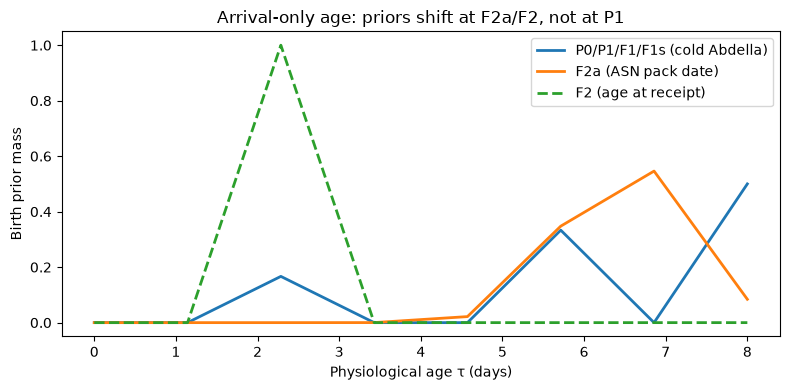

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(grid, cold, label="P0/P1/F1/F1s (cold Abdella)", lw=2)
ax.plot(grid, f2a_prior, label="F2a (ASN pack date)", lw=2)
ax.plot(grid, f2_prior, label="F2 (age at receipt)", lw=2, ls="--")
ax.set_xlabel("Physiological age τ (days)")
ax.set_ylabel("Birth prior mass")
ax.set_title("Arrival-only age: priors shift at F2a/F2, not at P1")
ax.legend()
fig.tight_layout()
plt.show()

## FIL-11 Stage A failure — in-store age did not contract

Before ADR **0105**, Stage A asked whether **in-store sales and waste** would **contract** the oldest-slot age posterior relative to the arrival prior. Under default Abdella mix and P1-like observations, the answer was **no** — the posterior **widened**.

From [`experiments/fil11_stage_a_result.md`](../experiments/fil11_stage_a_result.md):

- prior spread ≈ **1.98**
- posterior spread ≈ **2.23** (worse than prior)
- tight-spread control ≈ **0.00** (machinery works when given a tight prior)
- verdict: **FAIL** — Stages B/C ran later as diagnostics only

That failure is **why** production dropped in-store age learning. F2a/F2 “pass” Stage A-style checks via **receipt priors**, not via learning τ from shrink-gun totals or POS counts.

Scenario sweeps (`experiments/fil11_stage_a_scenarios.md`) show contraction can appear under extreme dwell/spoilage knobs — but those are historical diagnostics, not a reopen of the production gate.

In [7]:
if FIL11_RESULT.exists():
    print(FIL11_RESULT.read_text(encoding="utf-8"))
else:
    print("Missing:", FIL11_RESULT)

# FIL-11 Stage A — FAIL

Posterior did not contract under full Abdella mix relative to prior and tight-spread control. Stages B/C stopped per FIL-11=D as **gates**.
- prior_spread=1.9805
- posterior_spread=2.2316
- tight_posterior_spread=0.0000
- figure=/home/oliver/blog/blueberries-voi/figures/m1/fil11_contraction.png

## Honesty (production settle)

F2a/F2 age information comes from **priors** (arrival-prior / birth-prior injection at
receipt), not from learning ages off in-store sales and waste. P0/P1/F1 do **not** claim
in-store age learning / contraction as a production gate — Stage A success is count
calibration plus arrival-prior injection on the informed rungs.

## Follow-on (Oliver request)

Stages B and C were later run **as diagnostics only** (not a gate reopen; A remains FAIL).
See `experiments/fil11_stage_b_result.md` and `experiments/fil11_stage_c_result.md`.



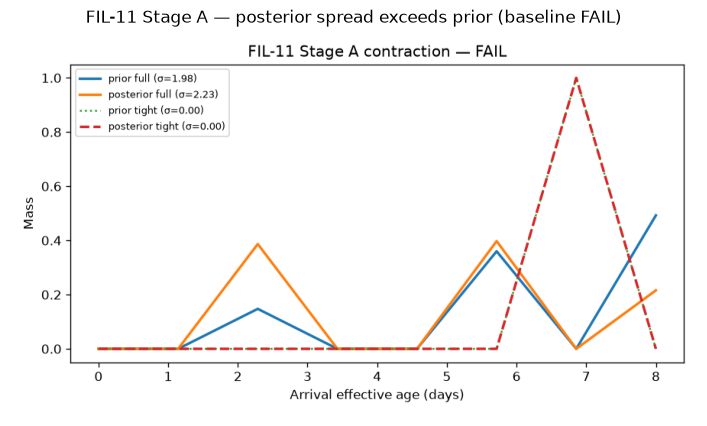

In [8]:
if FIG_FIL11.exists():
    img = plt.imread(FIG_FIL11)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("FIL-11 Stage A — posterior spread exceeds prior (baseline FAIL)")
    plt.show()
else:
    print("Figure not found:", FIG_FIL11)

## P0 feasibility-only particle weights

On **P0**, `waste_total` is **`UNOBSERVED`**. The production counts filter must **not** coerce missing waste to zero — that would be a false “zero waste today” update.

When only `sales_total` is observed, particle weights use **feasibility logic** (ADR **0105** / bakeoff implementation):

- If `0 ≤ sales_total ≤ on_hand`, weight contribution is **0** (log-likelihood flat) — sales totals alone are **age-free** under the feasibility model.
- If sales exceed on-hand, weight is **−∞** (impossible particle).

On **P1+**, both sales and waste totals are observed and weights use the full **exact sequential without-replacement** sales+waste likelihood.

This is a different question from age priors: P0 vs P1 changes **count inference**, while age rows stay on the cold mix until F2a/F2 receipt fields appear.

In [9]:
def p0_sales_weight(*, on_hand: int, sales_total: int) -> float:
    """Feasibility-only log-weight when waste is UNOBSERVED (P0)."""
    if 0 <= sales_total <= on_hand:
        return 0.0
    return float("-inf")


cases = [
    (50, 10, "feasible sales"),
    (50, 50, "sell-through boundary"),
    (50, 51, "impossible oversell"),
]

for on_hand, sales, label in cases:
    ll = p0_sales_weight(on_hand=on_hand, sales_total=sales)
    print(f"on_hand={on_hand:2d}, sales={sales:2d} → log w = {ll:6.1f}  ({label})")

on_hand=50, sales=10 → log w =    0.0  (feasible sales)
on_hand=50, sales=50 → log w =    0.0  (sell-through boundary)
on_hand=50, sales=51 → log w =   -inf  (impossible oversell)


## Belief semantics after the pivot (ADR 0106)

Controllers, VOI, and the browser export still expose **`ShelfBelief`** with:

- `lot_counts` — filtered count belief
- `age_marginals` — shape `(L, K)` on `tau_grid`
- flat `L·K` wire via `flatten_shelf_belief` (ENG-01 unchanged)

**What changed is meaning, not shape.**

| Era | `age_marginals` meant |
|-----|------------------------|
| Pre-0105 (ADR 0092) | Mean-field **posteriors** updated by in-store sales/waste |
| Post-0105 / ADR 0106 | **Arrival priors** at birth, clocked forward — Dirac / F2a / cold mix |

**B-state** still uses `shelf_belief_from_oracle` — Dirac rows on the true τ vector — as the interpretability ceiling (“how close does rung X get to knowing the shelf exactly?”).

Plain English for readers: **`age_marginals` tell you what receipt information assumed about age**, not what today’s POS scan “learned” about it.

## Takeaways for the blog post

1. **One filter, fair rungs** — `RichObs` + `mask_for`; missing ≠ zero.
2. **Business ladder** — books → shrink gun → Sunrise POS/shrink scans → ASN pack date → age at receipt.
3. **Arrival-only pivot** — stop claiming in-store age learning; F2a/F2 inject τ at receipt.
4. **FIL-11 Stage A FAIL** — documented blow-up under P1-like data; motivates the pivot.
5. **P0 weights** — feasibility-only on sales totals; waste must stay `UNOBSERVED`.
6. **ShelfBelief honesty** — same wire, arrival-prior semantics (ADR 0106).

Further reading: ADR [`0105`](../.team/adr/0105-arrival-only-age-counts-only-exact-wor.md), ADR [`0106`](../.team/adr/0106-shelfbelief-arrival-prior-age-exports.md), ADR [`0086`](../.team/adr/0086-m15-richobs-unobserved-masks.md).